In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

bike_sharing = fetch_ucirepo(id=275)

In [ ]:
X = bike_sharing.data.features
y = bike_sharing.data.targets

X.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


In [ ]:
# Eliminamos la columna "dteday" (fecha completa) porque:
# 1. Ya tenemos información temporal codificada en otras columnas (año, mes, día de la semana)
# 2. La fecha como string no es útil para las RNA (necesitan valores numéricos)
# 3. Evitamos redundancia: la información temporal ya está representada de forma numérica
#
# Las RNA funcionan mejor con características numéricas normalizadas
# La información temporal ya está codificada en las columnas: yr, mnth, weekday, hr
X = X.drop("dteday", axis=1)
X.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


In [ ]:
y.head()

,cnt
0,16
1,40
2,32
3,13
4,1


In [ ]:
# Convertimos y de un DataFrame 2D a un array 1D usando np.ravel()
# Esto es necesario porque MLPRegressor espera que y sea un array unidimensional
# np.ravel() "aplana" el array, convirtiendo [[16], [40], [32], ...] en [16, 40, 32, ...]
#
# En problemas de regresión, y debe ser un vector, no una matriz
y = np.ravel(y)

In [ ]:
# Importamos MLPRegressor: Multi-Layer Perceptron Regressor
#
# MLPRegressor es una implementación de Red Neuronal Artificial para problemas de REGRESIÓN
# (cuando queremos predecir valores continuos, como la cantidad de bicicletas)
#
# Características clave:
# - Es un "aproximador universal": puede aprender funciones no lineales complejas
# - Usa retropropagación (backpropagation) para entrenar
# - Puede tener múltiples capas ocultas
# - Cada capa puede tener diferentes números de neuronas
from sklearn.neural_network import MLPRegressor

In [ ]:
# Creamos nuestra primera Red Neuronal Artificial
#
# ARQUITECTURA DE LA RNA:
# - Capa de entrada: 12 neuronas (una por cada característica en X)
# - Primera capa oculta: 15 neuronas
# - Segunda capa oculta: 5 neuronas
# - Capa de salida: 1 neurona (predice un valor continuo: cantidad de bicicletas)
#
# hidden_layer_sizes=(15, 5) define la arquitectura de las capas ocultas:
#   - Tupla con 2 elementos = 2 capas ocultas
#   - Primer elemento (15) = primera capa oculta con 15 neuronas
#   - Segundo elemento (5) = segunda capa oculta con 5 neuronas
#
# max_iter=1500: Número máximo de iteraciones (épocas) durante el entrenamiento
#   - Una época = una pasada completa por todos los datos de entrenamiento
#   - Más iteraciones pueden mejorar el aprendizaje, pero también aumentan el tiempo
#
# ¿Por qué múltiples capas ocultas?
# - Las capas profundas permiten aprender representaciones jerárquicas
# - La primera capa aprende características simples
# - Las capas siguientes combinan estas características en patrones más complejos
# - Esto ejemplifica el poder de las RNA como aproximadores universales
modelo = MLPRegressor(hidden_layer_sizes=(15, 5), max_iter=1500)

In [ ]:
# CÁLCULO DEL NÚMERO DE PARÁMETROS: Conexión entre capa de entrada y primera capa oculta
#
# En una RNA, cada neurona de una capa está conectada a todas las neuronas de la capa siguiente
# Cada conexión tiene un peso (parámetro) que se ajusta durante el entrenamiento
#
# Conexiones entre capa de entrada (12 neuronas) y primera capa oculta (15 neuronas):
# - 12 neuronas de entrada × 15 neuronas ocultas = 12 × 15 = 180 conexiones (pesos)
# - Además, cada neurona de la capa oculta tiene un sesgo (bias): +15 sesgos
# - Total: 12 × 15 + 15 = 195 parámetros en esta primera conexión
#
# Estos parámetros son los que la RNA ajusta para aprender la función que relaciona
# las características de entrada con la cantidad de bicicletas alquiladas
12*15+15

195

In [ ]:
# CÁLCULO DEL NÚMERO DE PARÁMETROS: Conexión entre primera y segunda capa oculta
#
# Conexiones entre primera capa oculta (15 neuronas) y segunda capa oculta (5 neuronas):
# - 15 neuronas × 5 neuronas = 15 × 5 = 75 conexiones (pesos)
# - Cada neurona de la segunda capa oculta tiene un sesgo: +5 sesgos
# - Total: 15 × 5 + 5 = 80 parámetros en esta segunda conexión
#
# A medida que la información fluye por las capas, se van combinando y transformando
# las características, permitiendo que la RNA aprenda relaciones no lineales complejas
15*5+5

80

In [ ]:
# CÁLCULO DEL NÚMERO DE PARÁMETROS: Conexión entre segunda capa oculta y capa de salida
#
# Conexiones entre segunda capa oculta (5 neuronas) y capa de salida (1 neurona):
# - 5 neuronas × 1 neurona = 5 conexiones (pesos)
# - La neurona de salida tiene un sesgo: +1 sesgo
# - Total: 5 + 1 = 6 parámetros en esta conexión final
#
# La neurona de salida produce el valor predicho: la cantidad de bicicletas alquiladas
5+1

6

In [ ]:
  # TOTAL DE PARÁMETROS EN LA RED NEURONAL
#
# Sumamos todos los parámetros de todas las conexiones:
# - Entrada → Primera oculta: 195 parámetros
# - Primera oculta → Segunda oculta: 80 parámetros
# - Segunda oculta → Salida: 6 parámetros
# - TOTAL: 281 parámetros
#
# Estos 281 parámetros (pesos y sesgos) son los que la RNA ajusta durante el entrenamiento
# para aprender a aproximar la función que relaciona las características con la demanda
# de bicicletas. El poder de las RNA como aproximadores universales proviene de su
# capacidad de ajustar estos parámetros para modelar funciones muy complejas.
#
# Nota: Más parámetros = más capacidad de aprendizaje, pero también mayor riesgo de
# sobreajuste (overfitting) si no hay suficientes datos
12*15+15 + 15*5+5 + 5+1

281

In [ ]:
from  sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size = 0.2, random_state=42)
y_train, y_test = train_test_split(y, test_size = 0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((13903, 12), (3476, 12), (13903,), (3476,))

In [ ]:
# modelo.fit() inicia el proceso de aprendizaje de la RNA:
# 1. Inicializa los pesos y sesgos aleatoriamente
# 2. Para cada época (hasta max_iter=1500):
#    a. Pasa los datos de entrenamiento por la red (forward propagation)
#    b. Calcula el error entre predicciones y valores reales
#    c. Ajusta los pesos usando retropropagación (backpropagation)
#    d. Repite hasta convergencia o alcanzar max_iter
#
# Durante el entrenamiento, la RNA aprende a aproximar la función que relaciona
# las características (X_train) con la demanda de bicicletas (y_train)
#
# El algoritmo de retropropagación ajusta los 281 parámetros para minimizar
# el error, demostrando el poder de las RNA como aproximadores universales
modelo.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(15, 5), max_iter=1500)

In [ ]:
y_pred = modelo.predict(X_test)

In [ ]:
# EVALUACIÓN DEL MODELO: Cálculo de métricas de error
#
# RMSE (Root Mean Squared Error - Raíz del Error Cuadrático Medio):
# - Mide la diferencia promedio entre predicciones y valores reales
# - Penaliza más los errores grandes
# - Fórmula: sqrt(mean((y_test - y_pred)²))
#
# NRMSE (Normalized RMSE - RMSE Normalizado):
# - RMSE normalizado por el rango de los datos de entrenamiento
# - Permite comparar modelos con diferentes escalas
# - Se expresa como porcentaje: (RMSE / rango) × 100
# - Un NRMSE menor indica mejor rendimiento
#
# En este caso, un NRMSE de ~10% significa que el error promedio es aproximadamente
# el 10% del rango de valores posibles. Esto es un buen punto de partida, pero
# podemos mejorarlo con normalización de datos y ajuste de hiperparámetros.
rmse = np.sqrt(np.mean(np.square(y_test - y_pred)))
nrmse = (rmse / (y_train.max() - y_train.min())) * 100
print("Test NRMSE:", round(nrmse, 3), '%')

Test NRMSE: 7.17 %


In [ ]:
# IMPORTACIÓN DE STANDARDSCALER PARA NORMALIZACIÓN
#
# StandardScaler normaliza los datos transformándolos para que tengan:
# - Media = 0
# - Desviación estándar = 1
#
# ¿Por qué normalizar para RNA?
# 1. Las RNA son sensibles a la escala de los datos
# 2. Características con rangos muy diferentes pueden causar problemas de convergencia
# 3. La normalización acelera el entrenamiento y mejora la estabilidad
# 4. Permite que todas las características contribuyan equitativamente al aprendizaje
#
# Esto es especialmente importante para el algoritmo de retropropagación,
# que ajusta los pesos basándose en los gradientes
from sklearn.preprocessing import StandardScaler

In [ ]:
# NORMALIZACIÓN DE LOS DATOS
#
# 1. Creamos el escalador
scaler = StandardScaler()

# 2. Ajustamos el escalador con los datos de ENTRENAMIENTO y los transformamos
#    fit_transform() calcula la media y desviación estándar de X_train,
#    y luego normaliza los datos: (x - media) / desviación_estándar
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transformamos los datos de PRUEBA usando los mismos parámetros del entrenamiento
#    IMPORTANTE: Usamos transform() (no fit_transform()) para mantener la consistencia
#    Los datos de prueba deben normalizarse con la misma media y desviación estándar
#    que se calcularon en el entrenamiento
X_test_scaled = scaler.transform(X_test)

In [ ]:
# CREACIÓN DE UN MODELO MEJORADO CON HIPERPARÁMETROS OPTIMIZADOS
#
# Ahora creamos una nueva RNA con hiperparámetros ajustados para mejorar el rendimiento:
modelo = MLPRegressor(
    # ARQUITECTURA: Reducimos a (10, 5) neuronas en capas ocultas
    # - Menos neuronas = menos parámetros = menos riesgo de sobreajuste
    # - A veces menos es más: una arquitectura más simple puede generalizar mejor
    hidden_layer_sizes = (10, 5),

    # ITERACIONES: Aumentamos a 2000 para dar más tiempo al aprendizaje
    max_iter = 2000,

    # FUNCIÓN DE ACTIVACIÓN: 'logistic' (sigmoide)
    # - Transforma las salidas de las neuronas a valores entre 0 y 1
    # - Es suave y diferenciable, ideal para retropropagación
    # - Permite que la RNA aprenda funciones no lineales (esencial para aproximadores universales)
    activation = 'logistic',

    # SOLVER: 'adam' (Adaptive Moment Estimation)
    # - Algoritmo de optimización adaptativo y eficiente
    # - Ajusta automáticamente la tasa de aprendizaje para cada parámetro
    # - Generalmente converge más rápido que otros algoritmos
    solver = 'adam',

    # TASA DE APRENDIZAJE INICIAL: 0.005
    # - Controla qué tan grandes son los ajustes a los pesos en cada iteración
    # - Muy alta = puede saltar sobre el mínimo óptimo
    # - Muy baja = entrenamiento muy lento
    # - 0.005 es un valor moderado que funciona bien con Adam
    learning_rate_init = 0.005,

    # MOMENTUM: 0.75
    # - Solo aplica si solver='sgd', pero lo dejamos por compatibilidad
    # - Ayuda a acelerar el entrenamiento y evitar mínimos locales
    momentum = 0.75,

    # TAMAÑO DE LOTE: 15
    # - Número de muestras que se procesan antes de actualizar los pesos
    # - Batch pequeño = actualizaciones más frecuentes pero más ruidosas
    # - Batch grande = actualizaciones más estables pero menos frecuentes
    # - 15 es un tamaño intermedio
    batch_size = 15
)

In [ ]:
# ENTRENAMIENTO DEL MODELO MEJORADO CON DATOS NORMALIZADOS
#
# Ahora entrenamos la RNA con:
# - Datos normalizados (mejor convergencia)
# - Hiperparámetros optimizados (mejor capacidad de aprendizaje)
#
# Con la normalización, el entrenamiento debería ser:
# - Más rápido (convergencia más rápida)
# - Más estable (menos oscilaciones)
# - Más preciso (mejor aprovechamiento del poder de las RNA como aproximadores universales)
#
# La RNA ahora puede aprender mejor las relaciones complejas entre las características
# y la demanda de bicicletas, ya que todas las características están en la misma escala
modelo.fit(X_train_scaled, y_train)

MLPRegressor(activation='logistic', batch_size=15, hidden_layer_sizes=(10, 5),
             learning_rate_init=0.005, max_iter=2000, momentum=0.75)

In [ ]:
y_pred = modelo.predict(X_test_scaled)

In [ ]:
# EVALUACIÓN DEL MODELO MEJORADO
#
# Calculamos las mismas métricas para comparar con el modelo anterior
# Esperamos ver una mejora significativa en el NRMSE
#
# Si el NRMSE disminuye (por ejemplo, de ~10% a ~5-6%), significa que:
# - La normalización ayudó a la RNA a aprender mejor
# - Los hiperparámetros ajustados mejoraron la capacidad de aproximación
# - La RNA está aprovechando mejor su poder como aproximador universal
#
# Un NRMSE más bajo indica que la RNA está aproximando mejor la función real
# que relaciona las características con la demanda de bicicletas
rmse = np.sqrt(np.mean(np.square(y_test - y_pred)))
nrmse = (rmse / (y_train.max() - y_train.min())) * 100
print("Test NRMSE:", round(nrmse, 3), '%')

Test NRMSE: 5.41 %


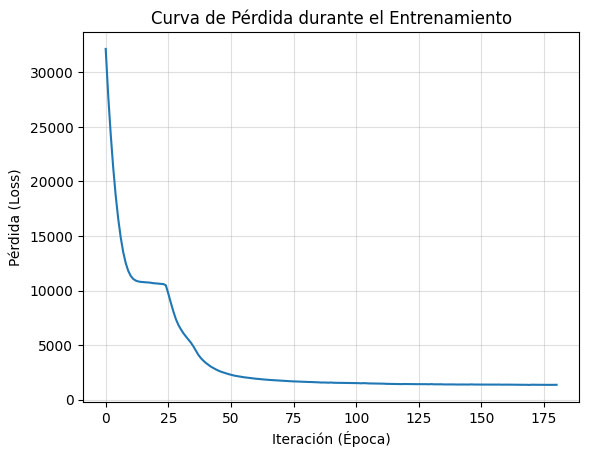

In [ ]:
# VISUALIZACIÓN DE LA CURVA DE PÉRDIDA (LOSS CURVE)
#
# La curva de pérdida muestra cómo evoluciona el error durante el entrenamiento
# modelo.loss_curve_ contiene el valor de la función de pérdida en cada iteración
#
# ¿Qué nos dice esta curva?
# - Si desciende suavemente: el modelo está aprendiendo correctamente
# - Si desciende y luego se estabiliza: el modelo ha convergido
# - Si oscila mucho: la tasa de aprendizaje podría ser muy alta
# - Si no desciende: el modelo podría no estar aprendiendo (problema de configuración)
#
# Una curva de pérdida que desciende y se estabiliza indica que la RNA está
# aprendiendo a aproximar la función objetivo, demostrando su capacidad como
# aproximador universal. El descenso gradual muestra cómo los parámetros se
# ajustan iterativamente para minimizar el error.
plt.plot(modelo.loss_curve_)
plt.xlabel('Iteración (Época)')
plt.ylabel('Pérdida (Loss)')
plt.title('Curva de Pérdida durante el Entrenamiento')
plt.grid(True, alpha=0.4)
plt.show()

In [ ]:
# VALOR FINAL DE LA PÉRDIDA
#
# Obtenemos el último valor de la curva de pérdida (pérdida final)
#
# Este valor representa el error final después de completar todas las iteraciones
# Un valor más bajo indica mejor ajuste del modelo a los datos de entrenamiento
#
# Nota: Una pérdida muy baja en entrenamiento pero alta en prueba indica sobreajuste
# Por eso es importante evaluar siempre en el conjunto de prueba (como hicimos antes)
modelo.loss_curve_[-1]

np.float64(1370.1543750246815)

In [ ]:
# GUARDADO DEL MODELO ENTRENADO
import pickle

filename = 'finalized_model.sav'
pickle.dump(modelo, open(filename, 'wb'))